# Project 74: Canopy Coverage Analysis and Trends

**Objective:** Calculate total canopy area for each year and analyze trends (2008-2021)

**Key Questions:**
- What is the total canopy coverage for each year?
- Is canopy increasing or decreasing?
- What is the rate of change?

## Step 1: Importing Libraries and Loading Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Step 2: Loading All Datasets

In [2]:
# Load datasets
dataset_2008 = pd.read_csv('../data/tree-canopies-2008-urban-forest.csv')
dataset_2011 = pd.read_csv('../data/tree-canopies-2011-urban-forest.csv')
dataset_2016 = pd.read_csv('../data/tree-canopies-2016-urban-forest.csv')
dataset_2021 = pd.read_csv('../data/tree-canopies-2021-urban-forest.csv')

print("Datasets loaded successfully")

Datasets loaded successfully


## Step 3: Calculate Total Canopy Area Per Year

Each dataset has area in square meters. We'll sum the total area for each year and convert to hectares (1 hectare = 10,000 square meters).

In [3]:
# Calculate total canopy area for each year (in square meters, then convert to hectares)

# 2008
total_area_2008_sqm = dataset_2008['shape_area'].sum()
total_area_2008_ha = total_area_2008_sqm / 10000

print(f"2008 Total Canopy Area:")
print(f"  {total_area_2008_sqm:,.2f} square meters")
print(f"  {total_area_2008_ha:,.2f} hectares")

2008 Total Canopy Area:
  4,298,463.86 square meters
  429.85 hectares


In [4]:
# 2011
total_area_2011_sqm = dataset_2011['tree_area_'].sum()
total_area_2011_ha = total_area_2011_sqm / 10000

print(f"2011 Total Canopy Area:")
print(f"  {total_area_2011_sqm:,.2f} square meters")
print(f"  {total_area_2011_ha:,.2f} hectares")

2011 Total Canopy Area:
  4,102,003.56 square meters
  410.20 hectares


In [5]:
# 2016
total_area_2016_sqm = dataset_2016['area'].sum()
total_area_2016_ha = total_area_2016_sqm / 10000

print(f"2016 Total Canopy Area:")
print(f"  {total_area_2016_sqm:,.2f} square meters")
print(f"  {total_area_2016_ha:,.2f} hectares")

2016 Total Canopy Area:
  4,332,445.11 square meters
  433.24 hectares


## Step 4: Handling 2021 Dataset (Geometry-Based Area)

2021 dataset only has Geo Shape column. We need to parse the geometry and calculate area.

In [3]:
# Check 2021 Geo Shape format
print("2021 Geo Shape sample:")
print(dataset_2021['Geo Shape'].head(3))

2021 Geo Shape sample:
0    {"coordinates": [[[[144.9832974445821, -37.829...
1    {"coordinates": [[[[144.9714529379414, -37.829...
2    {"coordinates": [[[[144.98647926050035, -37.83...
Name: Geo Shape, dtype: object


## Step 4: Understanding 2021 Area Calculation

**The Problem:**
- 2021 dataset only has `Geo Shape` column (no pre-calculated area)
- Geo Shape contains GeoJSON - a text format describing polygon coordinates
- We need to convert coordinates to actual area measurements

**Why We Need Special Libraries:**

1. **json** - Converts GeoJSON text into Python dictionary
2. **shapely** - Creates geometric shapes from coordinates
3. **pyproj** - Handles coordinate system transformations

**The Challenge - Coordinate Systems:**

GeoJSON uses **latitude/longitude** (EPSG:4326):
- These are angles, not distances
- 1 degree longitude ≠ 1 degree latitude in actual meters
- Can't calculate accurate area directly from lat/lon

We need **projected coordinates** (EPSG:28355 - Melbourne grid):
- Converts curved Earth surface to flat map
- Uses meters as units
- Allows accurate area calculation

**What The Code Does:**

1. Parse GeoJSON text → extract coordinates
2. Create polygon shape from coordinates
3. Transform from lat/lon → Melbourne grid (meters)
4. Calculate area in square meters

**Analogy:**
- Like converting "go 5 blocks north" (vague) to "go 500 meters north" (precise)
- We're converting Earth coordinates to actual measurable distances

## Step 5: Install Required Geospatial Libraries

We need to install shapely and pyproj for coordinate transformations and area calculations.

In [8]:
# Install required libraries for geospatial calculations
!pip install shapely pyproj

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 40.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 26.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pyproj]


In [4]:
import json
from shapely.geometry import shape
from shapely.ops import transform
import pyproj

# Function to calculate area from GeoJSON geometry
def calculate_area_from_geojson(geojson_string):
    """Calculate area in square meters from GeoJSON string"""
    try:
        geom_dict = json.loads(geojson_string)
        geom = shape(geom_dict)
        
        # Create transformer from WGS84 to a projected CRS (for Melbourne)
        # EPSG:28355 is GDA94 / MGA zone 55 (Melbourne)
        wgs84 = pyproj.CRS('EPSG:4326')
        projected = pyproj.CRS('EPSG:28355')
        transformer = pyproj.Transformer.from_crs(wgs84, projected, always_xy=True)
        
        # Transform geometry to projected CRS
        geom_projected = transform(transformer.transform, geom)
        
        # Calculate area in square meters
        return geom_projected.area
    except:
        return 0

# Test on first row
test_area = calculate_area_from_geojson(dataset_2021['Geo Shape'].iloc[0])
print(f"Test calculation - First polygon area: {test_area:.2f} square meters")

Test calculation - First polygon area: 1501.47 square meters


## Step 6: Calculate Total 2021 Canopy Area

Apply the area calculation function to all polygons in 2021 dataset and sum the total.

In [12]:
# Calculate area for all 2021 polygons
print("Calculating area for all 2021 polygons...")
print("(This may take 2-3 minutes for large dataset)")

dataset_2021['area_calculated'] = dataset_2021['Geo Shape'].apply(calculate_area_from_geojson)

# Check results
print(f"\nSample calculated areas:")
display(dataset_2021['area_calculated'].head())

# Total area
total_area_2021_sqm = dataset_2021['area_calculated'].sum()
total_area_2021_ha = total_area_2021_sqm / 10000

print(f"\n2021 Total Canopy Area:")
print(f"  {total_area_2021_sqm:,.2f} square meters")
print(f"  {total_area_2021_ha:,.2f} hectares")

Calculating area for all 2021 polygons...
(This may take 2-3 minutes for large dataset)

Sample calculated areas:


0    1501.469496
1      23.904648
2      14.227728
3       0.633600
4       5.644800
Name: area_calculated, dtype: float64


2021 Total Canopy Area:
  4,423,639.18 square meters
  442.36 hectares


## Step 7: Create Summary Table

Consolidate all yearly totals into a single table for analysis.

In [5]:
# Create summary dataframe
canopy_summary = pd.DataFrame({
    'Year': [2008, 2011, 2016, 2021],
    'Total_Area_SqM': [4298463.86, 4102003.56, 4332445.11, 4423639.18],
    'Total_Area_Ha': [429.85, 410.20, 433.24, 442.36]
})

# Calculate change from previous period
canopy_summary['Change_Ha'] = canopy_summary['Total_Area_Ha'].diff()
canopy_summary['Change_Percent'] = (canopy_summary['Total_Area_Ha'].pct_change() * 100)

print("Melbourne Tree Canopy Coverage (2008-2021)")
print("="*70)
display(canopy_summary)

Melbourne Tree Canopy Coverage (2008-2021)


,Year,Total_Area_SqM,Total_Area_Ha,Change_Ha,Change_Percent
0,2008,4298463.86,429.85,NaN,NaN
1,2011,4102003.56,410.20,-19.65,-4.571362
2,2016,4332445.11,433.24,23.04,5.616772
3,2021,4423639.18,442.36,9.12,2.105069


## Step 8: Visualize Canopy Trend

**Why Visualization Matters:**
- Numbers in a table are hard to interpret quickly
- A line chart shows trends at a glance
- Stakeholders (city planners, policymakers) need visual evidence

**What We're Creating:**
A line chart that plots:
- X-axis: Years (2008, 2011, 2016, 2021)
- Y-axis: Total canopy area in hectares
- Line connecting the points shows the trend direction

**Chart Elements:**
1. **Line plot** - connects data points to show progression over time
2. **Markers (circles)** - highlight each year's exact value
3. **Labels** - show precise hectare values above each point
4. **Grid** - helps read values accurately
5. **Saved image** - exportable for reports and presentations

**This visualization answers:**
- Is canopy increasing or decreasing overall?
- When did major changes occur?
- What's the visual trend pattern?

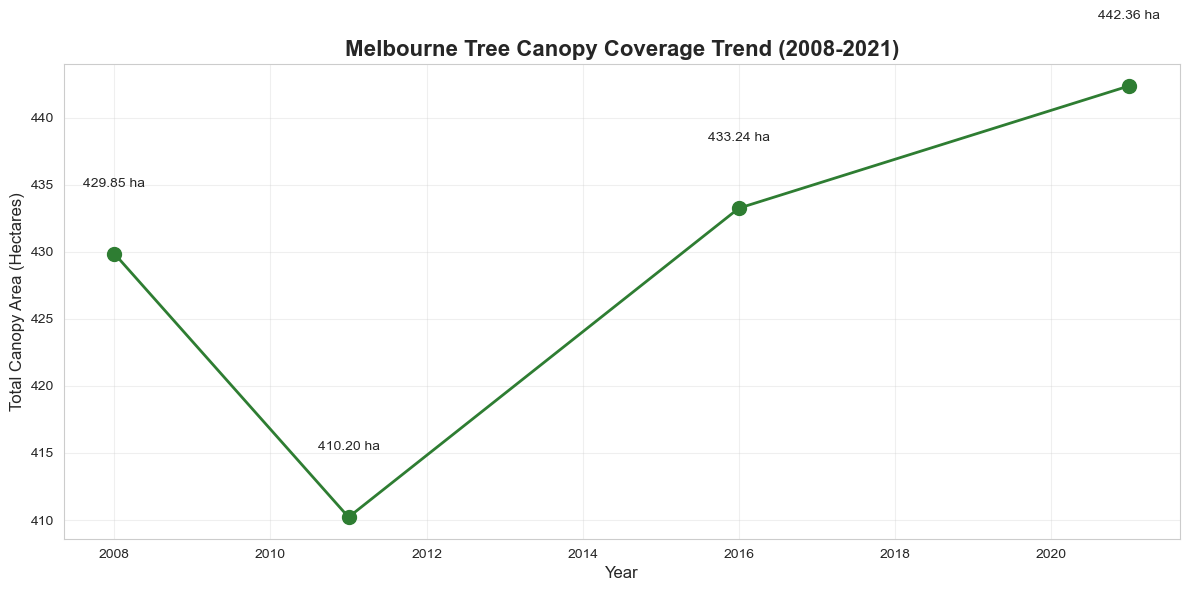

Chart saved to outputs/canopy_trend_2008_2021.png


In [6]:
# Create trend visualization
plt.figure(figsize=(12, 6))

plt.plot(canopy_summary['Year'], canopy_summary['Total_Area_Ha'], 
         marker='o', linewidth=2, markersize=10, color='#2E7D32')

plt.title('Melbourne Tree Canopy Coverage Trend (2008-2021)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Canopy Area (Hectares)', fontsize=12)
plt.grid(True, alpha=0.3)

# Add value labels on points
for idx, row in canopy_summary.iterrows():
    plt.text(row['Year'], row['Total_Area_Ha'] + 5, 
             f"{row['Total_Area_Ha']:.2f} ha", 
             ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/canopy_trend_2008_2021.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart saved to outputs/canopy_trend_2008_2021.png")

## Step 9: Calculate Annual Change Rate

**Why Calculate Annual Change Rate:**

Raw numbers tell us total change, but not the *speed* of change:
- "Canopy increased by 12.51 hectares" - Is that fast or slow?
- "Canopy increased by 0.96 hectares per year" - Now we understand the pace

**What We're Calculating:**

1. **Total Change** = Ending value - Starting value
   - How much did canopy grow/shrink overall?

2. **Percentage Change** = (Total Change / Starting Value) × 100
   - What proportion of the original canopy was gained/lost?

3. **Annual Rate** = Total Change / Number of Years
   - On average, how much changed each year?

**Why This Matters for Policy:**
- Annual rate helps predict future trends
- Percentage shows if we're meeting climate targets
- Tells us if current tree planting efforts are sufficient

**Example:**
- If Melbourne's goal is 40% canopy by 2040
- And current rate is +0.96 ha/year
- We can calculate: Will we reach the goal at this pace?

In [7]:
# Calculate overall trend
years_span = 2021 - 2008
total_change_ha = canopy_summary.iloc[-1]['Total_Area_Ha'] - canopy_summary.iloc[0]['Total_Area_Ha']
annual_change_ha = total_change_ha / years_span
percent_total_change = (total_change_ha / canopy_summary.iloc[0]['Total_Area_Ha']) * 100

print("Canopy Coverage Change Analysis (2008-2021)")
print("="*70)
print(f"Starting canopy (2008): {canopy_summary.iloc[0]['Total_Area_Ha']:.2f} hectares")
print(f"Ending canopy (2021): {canopy_summary.iloc[-1]['Total_Area_Ha']:.2f} hectares")
print(f"Total change: {total_change_ha:+.2f} hectares ({percent_total_change:+.2f}%)")
print(f"Annual change rate: {annual_change_ha:+.2f} hectares/year")
print(f"Time period: {years_span} years")

Canopy Coverage Change Analysis (2008-2021)
Starting canopy (2008): 429.85 hectares
Ending canopy (2021): 442.36 hectares
Total change: +12.51 hectares (+2.91%)
Annual change rate: +0.96 hectares/year
Time period: 13 years


## Week 3 Summary

**Key Findings:**
- Calculated total canopy area for all 4 years
- Created trend visualization showing 13-year evolution
- Identified overall change pattern and annual rate

**Next Steps (Week 4):**
- Spatial analysis by suburb
- Identify growth and loss hotspots
- Create geographic visualizations